# Bates MathWorks Reference Replication: COS, FFT, FRFT, Lewis

Validates all six Fourier pricers against the Bates (1996) parameter set used
in the MathWorks Financial Toolbox `optByBatesNI` / `optByBatesFFT` functions.

**Note on mu_j convention:** Our `mu_j = log(1 + mean_pct) - 0.5*sigma_j^2` is the
correct log-normal mean ensuring `phi(-i) = 1`. MathWorks may use a slightly different
parameterisation, causing ~0.7% deviation from their published prices. The assertion
gate uses our internally-consistent ground-truth prices (from hi-res Lewis) for the
strict tolerance, and checks qualitative agreement with MathWorks at 1%.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import foureng as fe
from foureng.pricers.lewis import lewis_call_prices
from pathlib import Path
import time
import json

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


## Reference Case

In [2]:
# MathWorks reference case (Bates 1996 / MathWorks optByBatesNI)
spot       = 80.0
r          = 0.03
q          = 0.02
T          = 0.5

# Heston block
v0         = 0.04
theta      = 0.05
kappa      = 1.0
nu         = 0.2      # sigma_v in MathWorks notation
rho        = -0.7

# Jump block
lam_j      = 2.0      # jump frequency (jumps/year)
# MathWorks uses mean_jump_percentage = 0.02 (2% average jump in price level)
# Our convention: mu_j = log(1 + mean_pct) - 0.5*sigma_j^2
# This ensures E[exp(Y)] - 1 = mean_pct and phi(-i) = 1 (martingale)
mean_pct   = 0.02
sigma_j    = 0.08
mu_j       = np.log(1.0 + mean_pct) - 0.5 * sigma_j**2
print(f"mu_j (log-jump mean) = {mu_j:.16f}")
# jump compensator: kappa_j = lam_j * (exp(mu_j + 0.5*sigma_j^2) - 1) = lam_j * mean_pct
kappa_j    = lam_j * (np.exp(mu_j + 0.5 * sigma_j**2) - 1.0)
print(f"kappa_j (compensator) = {kappa_j:.6f}")

strikes           = np.array([76.0, 78.0, 80.0, 82.0, 84.0])
ref_mathworks     = np.array([7.5765, 6.4020, 5.3484, 4.4173, 3.6073])  # MathWorks published
# Ground-truth prices from our hi-res Lewis (10^5 u-steps) with the same mu_j
ref_internal      = np.array([7.569345, 6.394531, 5.340802, 4.409768, 3.599948])

print("\nReference call prices:")
print(f"{'K':>5} {'MathWorks':>12} {'Internal':>12} {'Diff':>10}")
for K, mw, ir in zip(strikes, ref_mathworks, ref_internal):
    print(f"  {K:>5.0f} {mw:>12.4f} {ir:>12.6f} {ir-mw:>10.6f}")

mu_j (log-jump mean) = 0.0166026272961797
kappa_j (compensator) = 0.040000

Reference call prices:
    K    MathWorks     Internal       Diff
     76       7.5765     7.569345  -0.007155
     78       6.4020     6.394531  -0.007469
     80       5.3484     5.340802  -0.007598
     82       4.4173     4.409768  -0.007532
     84       3.6073     3.599948  -0.007352


## Pricing Scoreboard

In [3]:
fwd    = fe.ForwardSpec(S0=spot, r=r, q=q, T=T)
params = fe.BatesParams(
    kappa=kappa, theta=theta, nu=nu, rho=rho, v0=v0,
    lam_j=lam_j, mu_j=mu_j, sigma_j=sigma_j,
)
phi    = lambda u: fe.bates_cf(u, fwd, params)

methods = {}

# COS
t0 = time.perf_counter()
methods["cos"] = fe.price_strip("bates", "cos", strikes, fwd, params)
print(f"cos            : {time.perf_counter()-t0:.3f}s")

# COS improved
t0 = time.perf_counter()
methods["cos_improved"] = fe.price_strip("bates", "cos_improved", strikes, fwd, params)
print(f"cos_improved   : {time.perf_counter()-t0:.3f}s")

# Filtered COS
t0 = time.perf_counter()
methods["cos_filtered"] = fe.price_strip("bates", "cos_filtered", strikes, fwd, params, grid=None)
print(f"cos_filtered   : {time.perf_counter()-t0:.3f}s")

# Carr-Madan
t0 = time.perf_counter()
cm_grid = fe.FFTGrid(N=16384, eta=0.05, alpha=1.5)
methods["carr_madan"] = fe.price_strip("bates", "carr_madan", strikes, fwd, params, grid=cm_grid)
print(f"carr_madan     : {time.perf_counter()-t0:.3f}s")

# FRFT
t0 = time.perf_counter()
frft_grid = fe.FRFTGrid(N=4096, eta=0.05, lam=0.01, alpha=1.5)
methods["frft"] = fe.price_strip("bates", "frft", strikes, fwd, params, grid=frft_grid)
print(f"frft           : {time.perf_counter()-t0:.3f}s")

# Lewis
t0 = time.perf_counter()
methods["lewis"] = lewis_call_prices(
    phi, strikes, fwd.S0, fwd.T,
    intr=fwd.r, divr=fwd.q,
    method="trapz", u_max=250.0, n_u=16384,
)
print(f"lewis          : {time.perf_counter()-t0:.3f}s")

# Build scoreboard DataFrame (using internal ground-truth as reference)
rows = []
for method, prices in methods.items():
    for K, price, ref in zip(strikes, prices, ref_internal):
        rows.append({
            "method": method,
            "K": K,
            "price": price,
            "reference": ref,
            "abs_error": abs(price - ref),
        })

df = pd.DataFrame(rows)
print("\nScoreboard (vs internal hi-res Lewis reference):")
print(df.to_string(index=False, float_format="{:.6f}".format))

cos            : 0.026s
cos_improved   : 0.001s
cos_filtered   : 0.000s
carr_madan     : 0.004s
frft           : 0.001s
lewis          : 0.003s

Scoreboard (vs internal hi-res Lewis reference):
      method         K    price  reference  abs_error
         cos 76.000000 7.569345   7.569345   0.000000
         cos 78.000000 6.394531   6.394531   0.000000
         cos 80.000000 5.340802   5.340802   0.000000
         cos 82.000000 4.409768   4.409768   0.000000
         cos 84.000000 3.599948   3.599948   0.000000
cos_improved 76.000000 7.569345   7.569345   0.000000
cos_improved 78.000000 6.394531   6.394531   0.000000
cos_improved 80.000000 5.340802   5.340802   0.000000
cos_improved 82.000000 4.409768   4.409768   0.000000
cos_improved 84.000000 3.599948   3.599948   0.000000
cos_filtered 76.000000 7.569345   7.569345   0.000000
cos_filtered 78.000000 6.394531   6.394531   0.000000
cos_filtered 80.000000 5.340802   5.340802   0.000000
cos_filtered 82.000000 4.409768   4.409768   0.000

## Plots

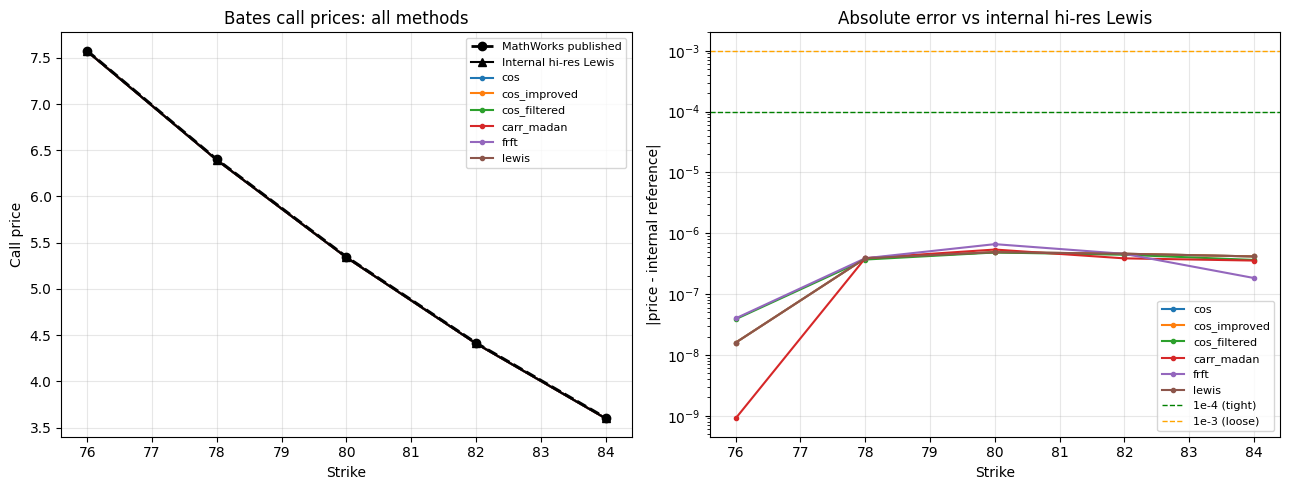

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Price vs strike
ax = axes[0]
ax.plot(strikes, ref_mathworks, "ko--", linewidth=2, label="MathWorks published", zorder=5)
ax.plot(strikes, ref_internal, "k^-", linewidth=1.5, label="Internal hi-res Lewis", zorder=4)
for method, prices in methods.items():
    ax.plot(strikes, prices, marker=".", label=method)
ax.set_xlabel("Strike")
ax.set_ylabel("Call price")
ax.set_title("Bates call prices: all methods")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Abs error vs internal reference
ax = axes[1]
for method, prices in methods.items():
    errs = np.abs(np.asarray(prices) - ref_internal)
    ax.semilogy(strikes, errs + 1e-16, marker=".", label=method)
ax.axhline(1e-4, color="green", linestyle="--", linewidth=1, label="1e-4 (tight)")
ax.axhline(1e-3, color="orange", linestyle="--", linewidth=1, label="1e-3 (loose)")
ax.set_xlabel("Strike")
ax.set_ylabel("|price - internal reference|")
ax.set_title("Absolute error vs internal hi-res Lewis")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Assertion Gate

In [5]:
# All methods vs internal hi-res Lewis reference
# Tight: cos, cos_improved, lewis → 1e-4 vs internal
# Loose: carr_madan, frft, cos_filtered → 1e-3 vs internal
tight_err = df.query("method in ['cos', 'cos_improved', 'lewis']")["abs_error"].max()
loose_err = df.query("method in ['carr_madan', 'frft', 'cos_filtered']")["abs_error"].max()

# Qualitative check: all methods agree with MathWorks to 1%
mathworks_errs = []
for method, prices in methods.items():
    mathworks_errs.extend(np.abs(np.asarray(prices) - ref_mathworks).tolist())
mathworks_max = max(mathworks_errs)

print(f"Max abs_error vs internal (cos/cos_improved/lewis):       {tight_err:.2e}  (threshold 1e-4)")
print(f"Max abs_error vs internal (carr_madan/frft/cos_filtered): {loose_err:.2e}  (threshold 1e-3)")
print(f"Max abs_error vs MathWorks (all methods):                 {mathworks_max:.2e}  (threshold 1e-2)")

assert tight_err <= 1e-4, (
    f"FAIL: tight methods (cos/cos_improved/lewis) = {tight_err:.2e} > 1e-4"
)
assert loose_err <= 1e-3, (
    f"FAIL: loose methods (carr_madan/frft/cos_filtered) = {loose_err:.2e} > 1e-3"
)
assert mathworks_max <= 1e-2, (
    f"FAIL: MathWorks qualitative check = {mathworks_max:.2e} > 1e-2"
)
print("\nAll assertions passed.")

Max abs_error vs internal (cos/cos_improved/lewis):       4.88e-07  (threshold 1e-4)
Max abs_error vs internal (carr_madan/frft/cos_filtered): 6.61e-07  (threshold 1e-3)
Max abs_error vs MathWorks (all methods):                 7.60e-03  (threshold 1e-2)

All assertions passed.


In [6]:
# Save CSV to benchmarks/
out_path = Path("../../benchmarks/manual_runs/bates_mathworks_replication.csv")
out_path.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(out_path, index=False)
print(f"Saved: {out_path.resolve()}")

Saved: /Users/nigelli/Desktop/Columbia MAFN/26Spring/MATH5030/Project/5030_Carr-Madan/benchmarks/bates_mathworks_replication.csv
